# Customer Churn - EDA

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/customer_churn_dataset.csv")
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [9]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [10]:
df["Churn"].value_counts()

Churn
0    33881
1    30493
Name: count, dtype: int64

## Churn by subscription type and contract length

In [11]:
df.groupby("Subscription Type")["Churn"].mean()

Subscription Type
Basic       0.482775
Premium     0.464964
Standard    0.473305
Name: Churn, dtype: float64

In [12]:
df.groupby("Contract Length")["Churn"].mean()

Contract Length
Annual       0.462167
Monthly      0.516087
Quarterly    0.440482
Name: Churn, dtype: float64

## Numeric feature distributions

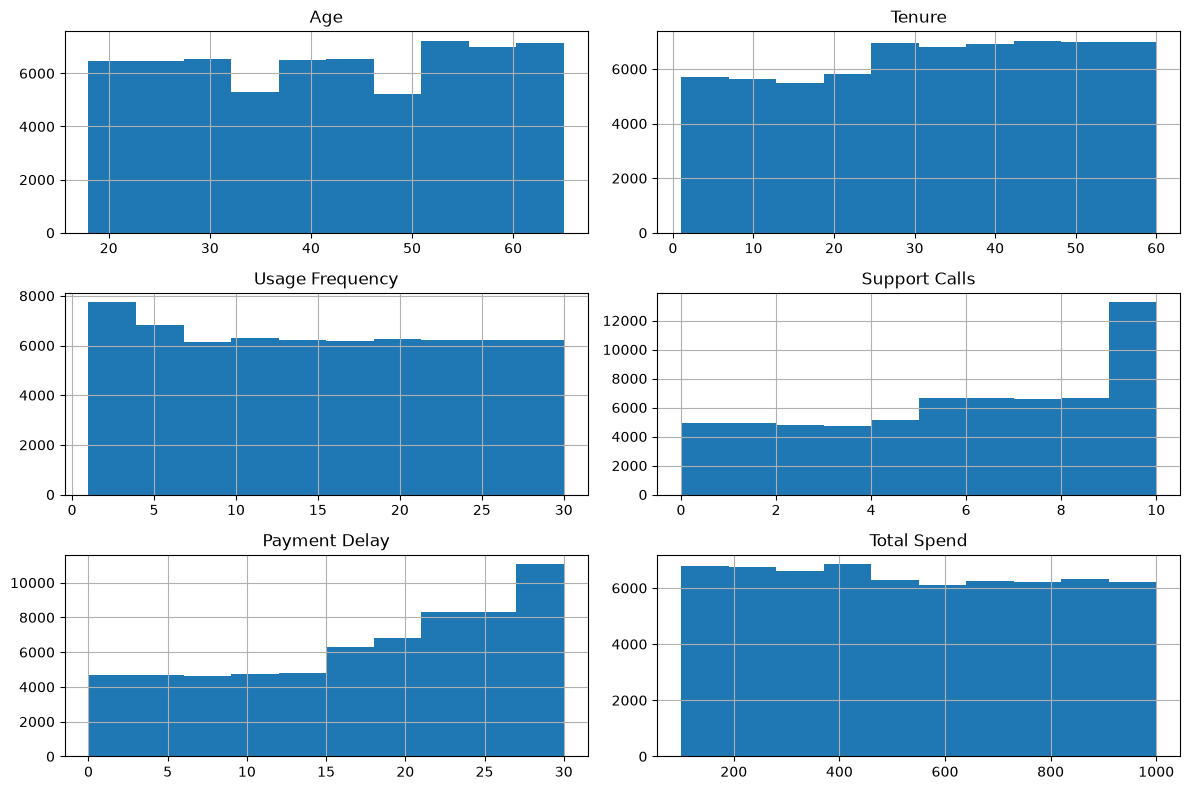

In [13]:
numeric_cols = ["Age", "Tenure", "Usage Frequency", "Support Calls", "Payment Delay", "Total Spend"]
df[numeric_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [14]:
df[numeric_cols + ["Churn"]].corr()["Churn"].sort_values(ascending=False)

Churn              1.000000
Payment Delay      0.557386
Support Calls      0.304631
Tenure             0.195327
Age                0.063457
Total Spend       -0.078867
Usage Frequency   -0.115098
Name: Churn, dtype: float64

In [17]:
# Save as CSV
df.to_csv(r"/home/prashanth-j-n/Desktop/Customer churn/customer_churn_prediction/data/processed_customer_data.csv", index=False)